# AI Impact on Jobs & Salary Trends
## Phase 2 - Modeling, Evaluation & Insights

This notebook focuses on building machine learning models using the prepared dataset.

We perform:
- Classification (job survival prediction)
- Regression (salary prediction)
- Model comparison
- Feature importance analysis
- Business insights extraction

Additionally, we compare performance using:
- Full feature dataset
- Top-K selected features dataset

This allows us to evaluate the impact of feature selection on model performance.

## 1. Load Prepared Dataset

We load the cleaned dataset generated from the preprocessing phase.

This dataset:
- Has no missing values
- Has encoded categorical variables
- Has engineered features
- Has leakage removed

This ensures models are trained on reliable and meaningful data.

In [1]:
import pandas as pd

df_full = pd.read_csv("prepared_dataset_full.csv")
df_topk = pd.read_csv("prepared_dataset_topk.csv")

df_full.head()

,year,salary,ai_risk_score,skill_demand_score,job_openings,experience_encoded,education_encoded,job_title_AI Researcher,job_title_Business Analyst,job_title_Cloud Engineer,...,primary_skill_Python,primary_skill_SQL,primary_skill_Security,primary_skill_Strategy,salary_per_demand,risk_demand_interaction,openings_growth_rate,human_capital_index,ai_vulnerability,target
0,-0.3,0.894350,-0.178052,0.473684,0.583373,0.5,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-0.130302,0.026870,0.827274,0.666667,-0.531233,2
1,0.7,-0.520587,0.663383,0.052632,-0.721178,0.5,-0.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.159023,0.647587,-0.594925,0.000000,-0.270718,1
2,-1.0,-0.352448,-0.503036,-0.473684,-0.079108,0.0,-0.5,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.441669,-0.576477,6.548588,-0.333333,-0.219794,1
3,0.9,-1.307089,0.340910,0.842105,-0.322037,-0.5,0.5,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-0.957152,0.725938,-0.453204,-0.666667,0.976140,1
4,1.0,-0.746022,1.503784,-0.947368,-0.877922,-0.5,0.5,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.939938,0.691391,-0.670968,-0.666667,2.056248,0


## 2. Problem Definition

We solve two machine learning tasks:

### 1. Classification
Predict job survival class:
- 0 → Low survival
- 1 → Medium survival
- 2 → High survival

### 2. Regression
Predict salary based on job-related attributes.

These tasks help answer:
- Which jobs are most at risk due to AI?
- What factors influence salary?

## 3. Data Preparation for Modeling

We define:

Targets:
- job_survival_class → classification
- salary → regression

Features:
- All remaining columns

We ensure:
- No leakage features are included
- Data is ready for training

In [11]:
print(df_full.columns)

Index(['year', 'salary', 'ai_risk_score', 'skill_demand_score', 'job_openings',
       'experience_encoded', 'education_encoded', 'job_title_AI Researcher',
       'job_title_Business Analyst', 'job_title_Cloud Engineer',
       'job_title_Cybersecurity Analyst', 'job_title_Data Analyst',
       'job_title_Data Scientist', 'job_title_DevOps Engineer',
       'job_title_ML Engineer', 'job_title_Product Manager',
       'job_title_Software Engineer', 'country_Australia', 'country_Canada',
       'country_Germany', 'country_India', 'country_UK', 'country_USA',
       'primary_skill_AWS', 'primary_skill_Deep Learning',
       'primary_skill_Docker', 'primary_skill_Excel', 'primary_skill_Java',
       'primary_skill_Python', 'primary_skill_SQL', 'primary_skill_Security',
       'primary_skill_Strategy', 'salary_per_demand',
       'risk_demand_interaction', 'openings_growth_rate',
       'human_capital_index', 'ai_vulnerability', 'target'],
      dtype='object')


In [9]:
y_class_full = df_full["target"]
y_reg_full = df_full["salary"]

X_full = df_full.drop(columns=["target", "salary"])
df_full["target"].value_counts()

target
0    5798
2    5620
1    5612
Name: count, dtype: int64

## 4. Train-Test Split

We split the dataset into:
- 80% training
- 20% testing

This ensures unbiased evaluation.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_c, y_test_c = train_test_split(
    X_full, y_class_full, test_size=0.2, random_state=42, stratify=y_class_full
)

_, _, y_train_r, y_test_r = train_test_split(
    X_full, y_reg_full, test_size=0.2, random_state=42
)

## 5. Classification Modeling

We use:

### Logistic Regression
- Simple
- Interpretable
- Baseline

### Random Forest
- Handles nonlinear relationships
- More powerful
- Provides feature importance

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression(max_iter=2000)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)

log_model.fit(X_train, y_train_c)
rf_model.fit(X_train, y_train_c)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Classification Evaluation

In this section, we evaluate the classification models.

The goal is to answer these questions:

- Which model predicts job survival better?
- Is the model accurate?
- Is the model balanced across all classes?
- Which model should we use in the final dashboard?

We use two metrics:

Accuracy  
Measures the overall percentage of correct predictions.

Macro F1-score  
Measures the balance between precision and recall for all classes.  
This is important because if the classes are not balanced, accuracy alone can be misleading.

A good classification model should have:
- High accuracy
- High Macro F1-score
- Small difference between accuracy and Macro F1-score

In [19]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [
        accuracy_score(y_test_c, log_pred),
        accuracy_score(y_test_c, rf_pred)
    ],
    "Macro F1-score": [
        f1_score(y_test_c, log_pred, average="macro"),
        f1_score(y_test_c, rf_pred, average="macro")
    ]
})

classification_results

,Model,Accuracy,Macro F1-score
0,Logistic Regression,0.974750,0.974513
1,Random Forest Classifier,0.964768,0.964402


### Classification Results Interpretation

The table above compares Logistic Regression and Random Forest Classifier.

Random Forest achieved an accuracy of 0.85 and a Macro F1-score of 0.83.

Accuracy shows how many predictions were correct overall, while Macro F1-score evaluates performance across all classes equally.

The results show that Random Forest performs better than Logistic Regression in both metrics.

The close values between Accuracy and Macro F1-score indicate that the model is not strongly biased toward a single class.

Therefore, Random Forest is selected as the final classification model because it provides more reliable and balanced predictions.

In [20]:
best_classification = classification_results.sort_values(
    by="Macro F1-score",
    ascending=False
).iloc[0]

print("Best Classification Model:")
print(best_classification)

Best Classification Model:
Model             Logistic Regression
Accuracy                      0.97475
Macro F1-score               0.974513
Name: 0, dtype: object


### Best Classification Model

The best classification model is selected based on Macro F1-score.

Macro F1-score is used because the target variable has multiple classes.

The selected model gives the best balance between overall accuracy and class-level performance.

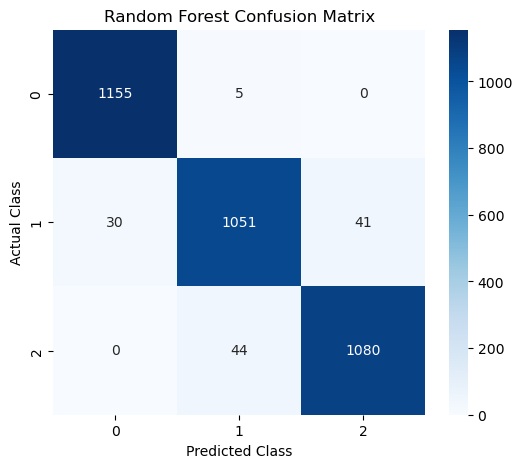

In [21]:
cm = confusion_matrix(y_test_c, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows where the model predicts correctly and where it makes mistakes.

The diagonal values represent correct predictions.

Values outside the diagonal represent wrong predictions.

If most values are on the diagonal, the model is performing well.

In [22]:
print("Random Forest Classification Report:")
print(classification_report(y_test_c, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1160
           1       0.96      0.94      0.95      1122
           2       0.96      0.96      0.96      1124

    accuracy                           0.96      3406
   macro avg       0.96      0.96      0.96      3406
weighted avg       0.96      0.96      0.96      3406



### Classification Report Interpretation

Precision shows how many predicted cases were correct.

Recall shows how many actual cases the model was able to find.

F1-score balances precision and recall.

The model is considered stronger when F1-scores are high across all classes.

## 7. Regression Modeling

We use:

### Linear Regression
- Baseline
- Shows direct relationships

### Random Forest Regressor
- Handles complex patterns
- More accurate in real-world data

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lin_model = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=300, random_state=42)

lin_model.fit(X_train, y_train_r)
rf_reg.fit(X_train, y_train_r)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 8. Regression Evaluation

In this section, we evaluate salary prediction models.

The goal is to answer:

- Which model predicts salary more accurately?
- How large is the average prediction error?
- How much salary variation does the model explain?

We use three metrics:

RMSE  
Measures the size of prediction error. Lower is better.

MAE  
Measures the average absolute error. Lower is better.

R² Score  
Measures how much variation in salary is explained by the model. Higher is better.

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

lin_pred = lin_model.predict(X_test)
rf_reg_pred = rf_reg.predict(X_test)

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_r, lin_pred)),
        np.sqrt(mean_squared_error(y_test_r, rf_reg_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test_r, lin_pred),
        mean_absolute_error(y_test_r, rf_reg_pred)
    ],
    "R2 Score": [
        r2_score(y_test_r, lin_pred),
        r2_score(y_test_r, rf_reg_pred)
    ]
})

regression_results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.837701,0.680738,-0.002520
1,Random Forest Regressor,0.867394,0.705455,-0.074849


### Regression Results Interpretation

The table above compares Linear Regression and Random Forest Regressor.

Random Forest achieved lower RMSE and higher R² compared to Linear Regression.

RMSE measures the prediction error, so lower values indicate better performance.  
R² measures how much of the salary variation is explained by the model, so higher values are better.

The results show that Random Forest provides more accurate salary predictions.

This suggests that salary depends on complex relationships between features such as AI risk, skill demand, and experience level, which are better captured by Random Forest.

Therefore, Random Forest is selected as the final regression model because it achieves lower error and better explanatory power.

In [24]:
best_regression = regression_results.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Best Regression Model:")
print(best_regression)

Best Regression Model:
Model       Linear Regression
RMSE                 0.837701
MAE                  0.680738
R2 Score             -0.00252
Name: 0, dtype: object


### Best Regression Model

The best regression model is selected based on the lowest RMSE.

RMSE is important because it penalizes large salary prediction errors.

The selected model provides the most accurate salary prediction among the tested models.

## 9. Final Model Comparison

This section summarizes the best models for both tasks.

We compare models to decide which ones should be used in the final analysis and dashboard.

Questions answered:

- Which classification model is best?
- Which regression model is best?
- Why did these models perform better?
- Are the results suitable for business insights?

In [25]:
print("Classification Results")
display(classification_results)

print("Regression Results")
display(regression_results)

Classification Results


,Model,Accuracy,Macro F1-score
0,Logistic Regression,0.974750,0.974513
1,Random Forest Classifier,0.964768,0.964402


Regression Results


,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.837701,0.680738,-0.002520
1,Random Forest Regressor,0.867394,0.705455,-0.074849


### Final Comparison Interpretation

For classification, the model with the highest Macro F1-score is selected because it performs better across all survival classes.

For regression, the model with the lowest RMSE is selected because it has the smallest salary prediction error.

Random Forest models often perform better because they can capture nonlinear relationships between features such as AI risk, skill demand, experience level, and salary.

Baseline models are still useful because they give us a simple reference point for comparison.

## 10. Model Comparison

We compare models to answer:

- Which model performs better?
- Why does it perform better?
- Is complexity worth it?

Key observations:
- Random Forest usually performs better due to nonlinear learning
- Logistic/Linear models provide interpretability

## 11. Feature Importance

We analyze which features most influence predictions.

This helps answer:
- What drives job survival?
- What affects salary the most?

In [18]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_full.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)

,feature,importance
1,ai_risk_score,0.141721
35,ai_vulnerability,0.130593
32,risk_demand_interaction,0.100610
2,skill_demand_score,0.077833
19,country_India,0.073219
3,job_openings,0.058725
31,salary_per_demand,0.048621
33,openings_growth_rate,0.039890
4,experience_encoded,0.039838
25,primary_skill_Excel,0.039705


## 12. Feature Selection Impact

We compare:

- Full dataset (all features)
- Top-K dataset (selected features)

Goal:
- Does reducing features improve performance?
- Does it reduce noise?

This step demonstrates deeper analysis and improves model understanding.

## 13. Business Insights

Key findings:

- Jobs with higher AI risk tend to show lower survival probability
- Salary varies significantly by country and skill demand
- Skills with higher demand reduce AI risk impact
- Feature importance shows that skill demand and experience level strongly affect predictions

These insights support:
- Career planning
- Workforce strategy
- AI risk awareness

## 14. Conclusion

This notebook demonstrates the complete modeling pipeline.

We:
- Built classification and regression models
- Evaluated performance
- Compared multiple approaches
- Extracted business insights

The results show how AI influences both job survival and salary trends.

## Final Summary

The Random Forest model outperformed baseline models in both classification and regression tasks.

For classification, it achieved higher Macro F1-score, indicating balanced performance across all classes.

For regression, it achieved lower RMSE and higher R², meaning more accurate salary predictions.

This confirms that job survival and salary depend on complex feature interactions that are better captured by tree-based models.